# G2++ Model

**Reference Paper:**
- Interest Rate Models - Brigo and Mercurio
- A General Gaussian Interest Rate Model Consistent with the Current Term Structure - Di Francesco. 2012
- Pricing Swaptions and Coupon Bond Options in Affine Term Structure Models - Schrager and Pelsser. 2006

<div style="background-color: #d5ffcd; padding: 10px; border-left: 4px solid #39ff07;">
⚠️ <b>Notes:</b> 
</div>

Done:
1. Montecarlo simulation
2. Bond prices / curves simulations
3. Binomial Tree (not done Trinomial)
4. Caps / Floors, pricing simulation and analytical
5. Swaptions, pricing simulation and analytical

Ongoing:
1. Clean document (verify coherent use of variables and notations, verify formulas)

To Do:
1. Get data and calibrate model (swaption, caps, floors prices, Bloomberg)
2. Deep hedging framework

Questions:

- Use swaptions data at a date x to calibrate model, then observe daily hedging against actual swap price?, hedge what sort of derivatives
- How do you use G2++ model for swaps, since G2++ models bond prices (do you account for swap spread)

Objectives:

"Does deep hedging outperform standard hedging because the market is complex, or just because the simulation method favors it?"

- Use different simulation proceedures (Monte Carlo, Trinomial Tree, Finite Difference, etc.)

<div style="background-color: #d5ffcd; padding: 10px; border-left: 4px solid #39ff07;">
⚠️ <b>Notes:</b> 
</div>

## Model Definition

The **G2++ model** is a two-factor Gaussian short-rate model. The short rate $r(t)$ is defined as:

$$
r(t) = x(t) + y(t) + \varphi(t), \quad r(0) = \varphi(0)
$$

where $\varphi(t)$ is a deterministic function fitted to the initial curve, and the two factors $x(t)$ and $y(t)$ follow a mean-reverting (Ornstein–Uhlenbeck) process:

$$
dx(t) = -ax(t)\,dt + \sigma\,dW_1(t), \quad x(0) = 0
$$

$$
dy(t) = -by(t)\,dt + \eta\,dW_2(t), \quad y(0) = 0
$$

and $dW_1(t)\,dW_2(t) = \rho\,dt$.



The explicit solution for $x(t)$, $y(t)$ conditional on $\mathcal{F}_s$ is

$$
x(t) = x(s)e^{-a(t-s)} + \sigma \int_s^t e^{-a(u-s)} dW_1(u)
$$
$$
y(t) = y(s)e^{-b(t-s)} + \eta \int_s^t e^{-b(u-s)} dW_2(u)
$$


## Parameters

| Parameter | Description |
|-----------|-------------|
| $a$ | Mean-reversion speed of factor $x$ |
| $b$ | Mean-reversion speed of factor $y$ |
| $\sigma$ | Volatility of factor $x$ |
| $\eta$ | Volatility of factor $y$ |
| $\rho$ | Correlation between $W_1$ and $W_2$ |
| $\varphi(t)$ | Deterministic shift fitted to the initial yield curve |


## Model Assumptions

1. Two-factor Gaussian model
    - The short rate is driven by 2 sources or randomness, making it more flexible versus One-factor models. $x(t)$ represent shorter term rates while $y(t)$ represents longer terms
2. Normally distributed rates
    - $x(t)$ and $y(t)$ are Gaussian. This implies possibility of negative rates
3. Mean reversion
    - Both $x(t)$ and $y(t)$ are mean reverting to zero. Generally, a >> b such that mean reversion in the short term is greater than in the long term
4. Constant parameters 
    - $a$, $b$, $\sigma$, $\eta$ and $\rho$ are constant over time
5. Perfect fit to initial yield or rates curve
    - $\varphi (t)$ is a deterministic function chosen such that the model fits the initial curve. Since $x(t)$ and $y(t)$ are both stochastic and mean reverting to zero, $\mathbb{E}[r(t) \mid \mathcal{F}_0] = \varphi (t)$
6. Correlation between short term and long term rates
    - The two Brownian motions are correlated through $dW_1(t)dW_2(t) = \rho dt$
7. No jumps
    - Rates move continuously, no sudden jumps
8. Risk-neutral measure
    - Model is specified under the risk neutral measure $Q$, so used mainly for pricing


## Advantages

- Can fit exactly the current yield curve
- Easy calculation for exact discretization, allowing simulation over larger time steps
- Zero Coupon Bond price available in closed form
- Closed form solution for caps, floors, and swaptions under forward measure dynamic, making it better to calibrate to real market data


## Limitations

- Assumes Gaussian rates, real rates usually have fatter tails than Gaussian
- Only two factors, which might be limiting is some cases. For example, yield curve have one turning point leading to upward sloping, downward sloping, one hump or one trough. In practice, curve might have more than one turning point.
- Specified under risk-neutral measure $Q$, and no jumps, so not used for real event simulations (i.e. Market prices of risk is unspecified)


## Objectives

1. Simulate Monte Carlo
    - To observe behavior of the short rate under G2++ model. Change parameters discretionarely to observe changes in behavior
    - Monte Carlo simulation is used to price path dependant derivatives
2. Use Monte Carlo simulation to simulate a yield surface
    - The yield curve simulated under G2++ model has one turning point leading to either upward/downward sloping or hump/trough shape
3. Binomial Tree
    - Simulate a binomial tree under certain parameters
    - Trees are used to price early exercice derivatives (American style options)
    - Then, do trinomial tree (better for mean reversion processes)
4. Caps / Floors (Pricing and Calibration)
    - The goal of this section is to calibrate the model parameters based on current observed market price of caps/floors
    - Under Gn++ model, caplet / flooret have closed form formula
5. Swaptions (Pricing and Calibration)
    - The goal of this section is to calibrate the model parameters based on current observed market price of swaptions
    - Swaptions pricing under any most models don't have a closed form formula. In this case, we will approximate ATM swaptions into a simple formula
    - Understand behavior of the model based on whether it was calibrated on caps/floors or swaptions
6. Deep hedging


---
## Packages


In [489]:
## packages
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
%matplotlib widget
from scipy.stats import norm

## seed
np.random.seed(123)

---
# 1. Monte Carlo


### (a) Discretization
<!-- TODO: I can derive this formula, for x(t), multiply by e^at -->
$$
x(t + \Delta t) = x(t)e^{-a \Delta t} + \sigma\sqrt{\frac{1 - e^{-2a\Delta t}}{2a}}\, W_1
$$
$$
y(t + \Delta t) = y(t)e^{-b \Delta t} + \eta\sqrt{\frac{1 - e^{-2b\Delta t}}{2b}}\, W_2
$$
where
$$
W_1 = Z_1
$$
$$
W_2 = \rho Z_1 + \sqrt{1-\rho ^ 2} Z_2
$$
$$
Cov[W_1, W_2] = \rho
$$
with
$$
Z_1, Z_2 \sim \, II\mathcal{N}(0,1)
$$


### (b) Set Parameters (Discretionary)

In [490]:
# import numpy as np
# import matplotlib.pyplot as plt

# Real parameters should be calibrated to market data, 
# by the property of closed form solution for (caps, floors) or swaptions

## parameters
# phi(t)
def phi(t):
    return 0.03
# x(t)
a = 1.5
sigma = 0.04
# y(t)
b = 0.10
eta = 0.02
# correlation dW1, dW2
rho = -0.75
# time step
T = 10.0
N = 1000

### (c) Create Monte Carlo Function

In [491]:
## simulate paths
def G2_MonteCarlo(a, sigma, b, eta, rho, T, N, M=1):
 
    # time grid
    dt = T / N
    t = np.linspace(0, T, N + 1)

    # standard deviations
    std_x = sigma * np.sqrt((1 - np.exp(-2*a*dt))/(2*a))
    std_y = eta * np.sqrt((1 - np.exp(-2*b*dt))/(2*b))

    # random numbers and correlations
    Z1, Z2 = np.random.normal(size = (M, N)), np.random.normal(size = (M, N))
    W1 = Z1
    W2 = rho * Z1 + np.sqrt(1-rho**2) * Z2

    # simulate x(t), y(t) and r(t)
    x = np.zeros((M, N + 1))
    y = np.zeros((M, N + 1))
    r = np.zeros((M, N + 1))
    r[:, 0] = phi(0)

    for i in range(N):
        x[:, i+1] = x[:, i] * np.exp(-a*dt) + std_x * W1[:, i]
        y[:, i+1] = y[:, i] * np.exp(-b*dt) + std_y * W2[:, i]
        r[:, i+1] = x[:, i+1] + y[:,i+1] + phi(t[i+1])
    
    return t, x.T, y.T, r.T

### (d) Plot Results

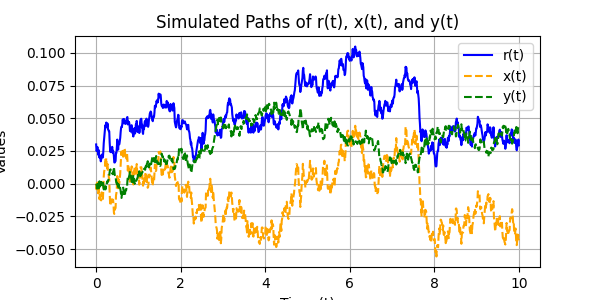

In [492]:
## plot results

t, x, y, r = G2_MonteCarlo(a, sigma, b, eta, rho, T, N, 2)

plt.figure(figsize=(6, 3)) 
plt.plot(t, r[:,0], label='r(t)', color='blue')
plt.plot(t, x[:,0], label='x(t)', color='orange', linestyle='--')
plt.plot(t, y[:,0], label='y(t)', color='green', linestyle='--')
plt.title('Simulated Paths of r(t), x(t), and y(t)')    
plt.xlabel('Time (t)')
plt.ylabel('Values')
plt.legend()
plt.grid()
plt.show()

---
# 2. Zero Coupon Bond


### (a) Closed Form Zero Coupon Bond Price Formula

The value at time $t$ of a zero-coupon bond maturing at T with unit face value is
$$
P(t,T) = \mathbb{E^Q}[e^{-\int_t^T r(s) ds} \mid \mathcal{F}_t]
$$
Lemma (proof in Brigo Mercurio):
$$
\int_t^T [x(u) + y(u)] du \sim \mathcal{N}(M(t,T),V(t,T))
$$
Which implies (MGF of Gaussian, and $\varphi (u)$ is deterministic)
$$
P(t,T) = \exp\left\{-\int_t^T \varphi (u) du - M(t,T) + \frac{1}{2} V(t,T)\right\}
$$
where
$$
\exp\left\{-\int_t^T \varphi (u) du\right\} = \frac{P^M(0,T) \exp\left\{-\frac{1}{2} V(0,T)\right\}}{P^M(0,t) \exp\left\{-\frac{1}{2} V(0,t)\right\}}
$$
with $M(t,T)$ and $V(t,T)$ deterministic functions of the parameters $a$, $b$, $\sigma$, $\eta$, $\rho$, $x(t)$, $y(t)$ 

<br>

*Sketch proof:*

Market price must match model price, and $M(0,T) = 0$

So,
$$
P^M(0,T) = \exp\left\{-\int_0^T \varphi (u) du\right\}\exp\left\{-\frac{1}{2} V(0,T)\right\}
$$

*Note : only integral of $\varphi (t)$ is needed for zero coupon bond prices, but we can derive the full $\varphi (t)$ function using the forward rate and a more complicated formula. But, this will likely lead to approximation error from interpolation and differenciation in the yield curve*

### (b) Get Bond Yield Surface

To simulate the whole yield curve, only need to simulate x(t) and y(t) and the yield curve at anytime t is determined analytically by the zero coupon bond price formula

In [493]:
def BondPrice(t, T, a, b, sigma, eta, rho, x_t, y_t):
    """
    Function to get bond price at time t, with maturity T, derived from x(t) and y(t)
    """

    def M(t, T, a, b, x_t, y_t):
        return ((1 - np.exp(-a*(T-t)))/a)*x_t + ((1 - np.exp(-b*(T-t)))/b)*y_t
    def V(t, T, a, b, sigma, eta, rho):
        term1 = (sigma**2 / a**2) * (T - t + (2/a)*np.exp(-a*(T-t)) - (1/(2*a))*np.exp(-2*a*(T-t)) - (3/(2*a)))
        term2 = (eta**2 / b**2) * (T - t + (2/b)*np.exp(-b*(T-t)) - (1/(2*b))*np.exp(-2*b*(T-t)) - (3/(2*b)))
        term3 = (2*rho*sigma*eta/(a*b)) * (T - t + (np.exp(-a*(T-t))-1)/a + (np.exp(-b*(T-t))-1)/b - (np.exp(-(a+b)*(T-t))-1)/(a+b))
        return term1 + term2 + term3
    global phi
    int_phi = phi(t)*(T-t)    # defined as a constant for simplicity, to be adjusted
    BondPrice = np.exp(-int_phi - M(t, T, a, b, x_t, y_t) + 0.5*V(t, T, a, b, sigma, eta, rho))

    return BondPrice

def BondYield(t, T, a, b, sigma, eta, rho, x_t, y_t):
    BondYield = -np.log(BondPrice(t, T, a, b, sigma, eta, rho, x_t, y_t)) / (T - t)
    return  BondYield


In [494]:
## Simulation of yield surface

# simulate paths
t, x, y, r = G2_MonteCarlo(a, sigma, b, eta, rho, T, N, 2)

# times and tenors
tenors = np.array([0.1, 0.25, 0.5, 1, 2, 3, 5, 7, 10])   #tenors where bond price will be calculated
t_times = np.arange(0, 12, 2)    #time points where yield curve will be calculated
# t_times = np.array([0,1]) #use for visualization of one yield curve at t=0 and t=1
t_index = np.array([np.argmin(np.abs(t - t_snap)) for t_snap in t_times]) # find closest time simulated versus time point of the curve

# yield surface matrix
yield_curves = np.zeros((len(t_times), len(tenors)))

# loop for each time point and tenor to calculate yield
for i, idx in enumerate(t_index):
    t_i = t[idx]  # current time
    x_i = x[idx, 0]  # x(t_i) for the first path
    y_i = y[idx, 0]  # y(t_i) for the first path
    T_vec = t_i + tenors   #maturity vector for each t_i

    yield_curves[i, :] = BondYield(t_i, T_vec, a, b, sigma, eta, rho, x_i, y_i)  #get yield at each t_i for each tenors

### (c) Plot Results

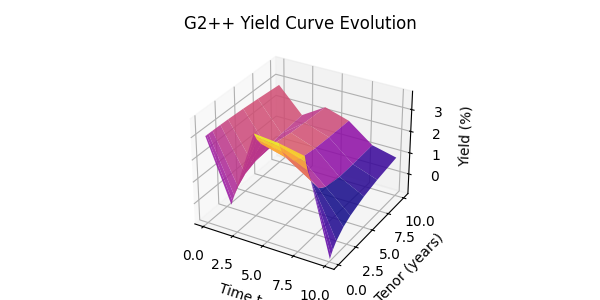

In [495]:
# from mpl_toolkits.mplot3d import Axes3D
# %matplotlib widget

# grid
T_grid, Tenor_grid = np.meshgrid(t_times, tenors, indexing = 'ij')

fig = plt.figure(figsize=(6, 3))
ax  = fig.add_subplot(111, projection='3d')
ax.plot_surface(T_grid, Tenor_grid, yield_curves * 100, cmap='plasma', alpha=0.85)
ax.set_xlabel('Time t')
ax.set_ylabel('Tenor (years)')
ax.set_zlabel('Yield (%)')
ax.set_title('G2++ Yield Curve Evolution')
plt.tight_layout()
plt.show()

---
# 3. Binomial Tree

### (a) Introduction to pricing trees

Trees are used in pratice to price exotic derivative (such as American options). Trees have deterministic paths, such that at every node, you know all possible future paths, with respective probabilities. Trees are priced by backward induction (from the payoff to time zero). First, determine the payoff vector, then at each node $n$, discount value of node $n+1$, then the value of the node $n$ is the maximum between the holding value (next period discounted) or the intrinsic value (exercice now, American option).

There is 2 methods to construct a tree. The first is to fixed step size $\Delta x$, and have varying probabilities to go up, down (binomial) or middle (trinomial). The second is the inverse, fixed the probabilities and let the step size $\Delta x$ be varying. In the following, I will be interested in fixed step size $\Delta x$. 

### (b) Two-dimensional binomial tree

For each process $x(t)$ and $y(t)$, we will build the tree by matching the following moments, for any $t$ and $\Delta t > 0$:
$$
\begin{cases}
\text{E}[x(t+\Delta t) \mid \mathcal{F}_t] = x(t)e^{-a\Delta t} \\
\text{Var}[x(t+\Delta t) \mid \mathcal{F}_t] = \dfrac{\sigma^2}{2a}(1 - e^{-2a\Delta t})
\end{cases}
$$

$$
\begin{cases}
\text{E}[y(t+\Delta t) \mid \mathcal{F}_t] = y(t)e^{-b\Delta t} \\
\text{Var}[y(t+\Delta t) \mid \mathcal{F}_t] = \dfrac{\eta^2}{2b}(1 - e^{-2b\Delta t})
\end{cases}
$$

$$
\begin{cases}
\text{Cov}[x(t+\Delta t), y(t+\Delta t) \mid \mathcal{F}_t] = \dfrac{\rho \sigma \eta}{a+b}(1 - e^{-(a+b)\Delta t})
\end{cases}
$$

By expanding up to first order in $\Delta t$ (negligible for small $\Delta t$), we have

$$
\begin{cases}
\text{E}[x(t+\Delta t) \mid \mathcal{F}_t] = x(t)(1 - a\Delta t) \\
\text{Var}[x(t+\Delta t) \mid \mathcal{F}_t] = \sigma^2 \Delta t
\end{cases}
$$

$$
\begin{cases}
\text{E}[y(t+\Delta t) \mid \mathcal{F}_t] = y(t)(1 - b\Delta t) \\
\text{Var}[y(t+\Delta t) \mid \mathcal{F}_t] = \eta^2 \Delta t
\end{cases}
$$
and

$$
\text{Cov}[x(t+\Delta t),\, y(t+\Delta t) \mid \mathcal{F}_t] = \sigma\eta\rho\,\Delta t
$$




We get the following probabilities

$$
\begin{cases}
p\,x(t+\Delta x) + (1-p)\,x(t-\Delta x) = x(t)(1 - a\Delta t) \\
p\,x(t+\Delta x)^2 + (1-p)\,x(t-\Delta x)^2 - [x(t)(1-a\Delta t)]^2 = \sigma^2\Delta t
\end{cases}
$$

$$
\begin{cases}
q\,y(t+\Delta y) + (1-q)\,y(t-\Delta y) = y(t)(1 - b\Delta t) \\
q\,y(t+\Delta y)^2 + (1-q)\,y(t-\Delta y)^2 - [y(t)(1-b\Delta t)]^2 = \eta^2\Delta t
\end{cases}
$$

Which leads to $\Delta x = \sigma \sqrt{\Delta t}$ and $\Delta y = \eta \sqrt{\Delta t}$






Then, we need to solve for the following probabilities for the pair $(x,y)$
- $(x(t) + \Delta x,\, y(t) + \Delta y)$ with probability $\pi_1$
- $(x(t) + \Delta x,\, y(t) - \Delta y)$ with probability $\pi_2$
- $(x(t) - \Delta x,\, y(t) + \Delta y)$ with probability $\pi_3$
- $(x(t) - \Delta x,\, y(t) - \Delta y)$ with probability $\pi_4$
  
  with $\pi_1 + \pi_2 + \pi_3 + \pi_4 = 1$
  
Which leads to

$$
\small
\small
\begin{cases}
\pi_1 = \dfrac{1+\rho}{4} - \dfrac{b\sigma y(t) + a\eta x(t)}{4\sigma\eta}\sqrt{\Delta t} \\[8pt]
\pi_2 = \dfrac{1-\rho}{4} + \dfrac{b\sigma y(t) - a\eta x(t)}{4\sigma\eta}\sqrt{\Delta t} \\[8pt]
\pi_3 = \dfrac{1-\rho}{4} - \dfrac{b\sigma y(t) - a\eta x(t)}{4\sigma\eta}\sqrt{\Delta t} \\[8pt]
\pi_4 = \dfrac{1+\rho}{4} + \dfrac{b\sigma y(t) + a\eta x(t)}{4\sigma\eta}\sqrt{\Delta t}
\end{cases}
$$

It is possible that $0 \leq \pi_i \leq 1$ is not satisfied for some value of $(x(t), y(t))$. This problem can be overcome by slightly changing the value $\rho$ such that the condition is fulfilled, or by setting to $0$ the $\pi_i < 0$ and normalizing the other probabilities so that they sum to $1$. This should not affect in any way the pricing of a general claim if we choose $\Delta t$ to be sufficiently small, and since negative $\pi_i$ occurs at extreme cases, which are negligible for large trees and options not too OTM.

### (c) Simulating a 2D Binomial tree

In [496]:
# payoff will be defined later based on the derivative to price
N_bin = 100  #default value
def BinomialTree(payoff, T=T, N=N_bin,
                 a=a, b=b, sigma=sigma, eta=eta, rho=rho):
    """
    2D Binomial Tree
    Node (i,j) at step time n: x = (2i-n)dx, y = (2j-n)dy
        this is from i: move up, n-i, move down, so position = i - (n-i) = 2i-n
    """
    dt = T/N
    dx = sigma * np.sqrt(dt)
    dy = eta * np.sqrt(dt)
    t = np.linspace(0, T, N+1)

    # terminal value at step N (time T), and payoff
    I, J = np.meshgrid(np.arange(N+1), np.arange(N+1), indexing = 'ij')
    V = payoff((2*I - N)*dx, (2*J - N)*dy, t[N])

    # Backward induction
    for n in range(N-1, -1, -1):
        I, J = np.meshgrid(np.arange(n+1), np.arange(n+1), indexing = 'ij')
        x = (2*I - n) * dx
        y = (2*J - n) * dy
        r = x + y + phi(t[n])

        # probabilities
        pi1 = (1+rho)/4 - (b*sigma*y + a*eta*x) / (4*sigma*eta) * np.sqrt(dt)
        pi2 = (1-rho)/4 + (b*sigma*y - a*eta*x) / (4*sigma*eta) * np.sqrt(dt)
        pi3 = (1-rho)/4 - (b*sigma*y - a*eta*x) / (4*sigma*eta) * np.sqrt(dt)
        pi4 = (1+rho)/4 + (b*sigma*y + a*eta*x) / (4*sigma*eta) * np.sqrt(dt)

        # make sure non-negative prob at extremes, and normalize if approx error:
        pi1 = np.maximum(pi1, 0); pi2 = np.maximum(pi2, 0)
        pi3 = np.maximum(pi3, 0); pi4 = np.maximum(pi4, 0)
        s = pi1 + pi2 + pi3 + pi4
        pi1 /= s; pi2 /= s; pi3 /= s; pi4 /= s

        # expected value
        Expected_V = (pi1 * V[1:n+2, 1:n+2] +    # x up, y up
                      pi2 * V[1:n+2, 0:n+1] +    # x up, y down
                      pi3 * V[0:n+1, 1:n+2] +    # x down, y up
                      pi4 * V[0:n+1, 0:n+1])     # x down, y down

        V_new = np.exp(-r * dt) * Expected_V

        V = np.zeros((N+1, N+1))
        V[:n+1, :n+1] = V_new

    return V[0,0]

---
# 4. Caps & Floors

### (a) Introduction to Caps / Floors

A caplet / flooret is an interest rate derivative giving its holder the right to pay a predetermined fixed rate at maturity and receiving the floating rate. A cap / floor is a sequence of caplets / floorets. A common strategy using caps and floors is to be long a cap and short a floor (a collar), hence limiting the risk of rates rising above the cap strike, but paying a minimum rate equal to the floor strike if rates fall below it. The premium received from selling the floor offsets the cost of buying the cap, often achieving a near zero-cost hedge.

Some model, including the Gn++ have a closed form formula for the pricing of caplet / flooret, under the $Q^T$ forward measure, making it efficient to calibrate to market data.

### (b) Pricing of Cap & Floor

**T-Forward dynamics** 

First, derive the dynamics of the G2++ model under the T-forward measure.

The Radon-Nikodym derivative is 
$$
\frac{dQ^T}{dQ} = \frac{B(0)P(T,T)}{B(T)P(0,T)} = \cdots = \exp\left\lbrace -\frac{1}{2}V(0,T) - \int_0^T[x(u) + y(u)]\,du \right\rbrace
$$
leading to the following dynamics
$$
dx(t) = \left[-ax(t) - \frac{\sigma^2}{a}(1 - e^{-a(T-t)}) - \rho\frac{\sigma \eta}{b}(1 - e^{-b(T-t)})\right]dt + \sigma dW_1^T(t)
$$
$$
dy(t) = \left[-by(t) - \frac{\eta^2}{b}(1 - e^{-b(T-t)}) - \rho\frac{\sigma \eta}{a}(1 - e^{-a(T-t)})\right]dt + \sigma dW_2^T(t)
$$
Moveover, explicit solutions are
$$
x(t) = x(s)e^{-a(t-s)} - M_x^T(s,t) + \sigma\int_s^t e^{-a(t-u)}dW_1^T(u)
$$
$$
y(t) = y(s)e^{-b(t-s)} - M_y^T(s,t) + \eta\int_s^t e^{-b(t-u)}dW_2^T(u)
$$
with deterministic functions $M_x^T(s,t)$ and $M_y^T(s,t)$

So that under $Q^T$, $r(t)$ conditional on $\mathcal{F}_s$ is normal with mean and variance given by
$$
{E^Q}^T\left[r(t) \mid \mathcal{F}_s\right] = 
x(s)e^{-a(t-s)} - M_x^T(s,t) + y(s)e^{-b(t-s)} - M_y^T(s,t)
$$
$$
Var^{Q^T}\left[r(t) \mid \mathcal{F}_s\right] = 
\frac{\sigma^2}{2a}\left[1 - e^{-2a(t-s)}\right] + \frac{\eta^2}{2b}\left[1 - e^{-2b(t-s)}\right] + \rho \frac{\sigma \eta}{a+b}\left[1 - e^{-(a+b)(t-s)}\right]
$$


**European zero coupon bond options**

The payoff of a European call option with maturity T and strike K on a zero coupon bond with unit face value at maturity S is given by
$$
ZBC(t,T_n,T_N,K) = P(t,T_n){E^Q}^T\left[{(P(T_n,T_N) - K)}^+ \mid \mathcal{F}_t\right]
$$
Since the dynamic of r(t) is Gaussian under the T-forward measure $Q^T$, so the bond price is lognormally distributed.

Thus, with Black's formula, we get the following European call option price
$$
\small
\begin{aligned}
ZBC_t(V,T_n,T_N,K) &= V\,P(t,T_N) \Phi \left(\frac{\ln \frac{P(t,T_N)}{KP(t,T_n)}}{\Sigma (t,T_n,T_N)} + \frac{1}{2} \Sigma (t,T_n,T_N)\right)
\\\\&
- K\,P(t,T_n) \Phi \left(\frac{\ln \frac{P(t,T_N)}{KP(t,T_n)}}{\Sigma (t,T_n,T_N)} - \frac{1}{2} \Sigma (t,T_n,T_N)\right)
\end{aligned}
$$

And a European put option price is 
$$
\small
\begin{aligned}
ZBP_t(V,T_n,T_N,K) &= K\,P(t,T_n) \Phi \left(-\frac{\ln \frac{P(t,T_N)}{KP(t,T_n)}}{\Sigma (t,T_n,T_N)} + \frac{1}{2} \Sigma (t,T_n,T_N)\right)
\\\\&
- V\,P(t,T_N) \Phi \left(-\frac{\ln \frac{P(t,T_N)}{KP(t,T_n)}}{\Sigma (t,T_n,T_N)} - \frac{1}{2} \Sigma (t,T_n,T_N)\right)
\end{aligned}
$$


**Caplets and Floorets**

In a short rate model, the simply-compounded rate for $[T_n, T_N]$ is:

$$L(T_n, T_N) = \frac{1}{\tau}\left(\frac{1}{P(T_n, T_N)} - 1\right)$$

The caplet pays when $L > K$, which is equivalent to $P(T_n, T_N) < K^*$ where $K^* = \frac{1}{1+\tau K}$. So the caplet is directly a put on the bond price:

$$\text{Caplet}_t(T_n, T_N, V, K) = V(1+\tau K)\cdot ZBP_t(1,\ T_n,\ T_N,\ K^*)$$

Similarly,

$$\text{Flooret}_t(T_n, T_N, V, K) = V(1+\tau K)\cdot ZBC_t(1,\ T_n,\ T_N,\ K^*)$$


The bond prices $P(t,T_n)$ and $P(t,T_N)$ are the G2++ closed-form bond prices, so the caplet is entirely expressed as a function of the short rate factors $x(t)$ and $y(t)$

Now, price caplet and flooret. A caplet is basically having the option to sell a bond (invest selling at strike to receive floating, pay fixed rate to broker) : fixed rate is lower than floating.

For example, at the cap expiry, you have to option to exercice and pay K for your next 3 months rate, or don't exercice and pay floating for your 3 months rate (exercice if strike K < Floating)



**Pricing of cap & floor**

A cap (floor) is a serie of independant caplets (floorets), so

$$\text{Cap}_t(T_0, T_k, V, K) = \sum_{i=1}^k \text{Caplet}_t(T_{i-1},\ T_i,\ V,\ K)$$

where caplet $i$ resets at $T_{i-1}$ and pays at $T_i$

Similarly, 

$$\text{Floor}_t(T_0, T_k, V, K) = \sum_{i=1}^k \text{Flooret}_t(T_{i-1},\ T_i,\ V,\ K)$$




### Parameters

In [497]:
# Cap Floor parameters
T_start = 1.0      # start of cap
T_end = 6          # end of cap (1Y into 5Y swaption)
freq  = 0.5        # semi-annual payments
K = 0.06           # cap strike
tenor = freq       # underlying rate tenor
M = 10000          # number of simulated paths for MonteCarlo
N_bin = 200        # number of steps in the binomial tree

pay_dates = np.arange(T_start + freq, T_end + freq/2, freq)
delta = np.full(len(pay_dates), freq)  # year fraction for each payment
# strike (ATM forward swap rate at t=0)
P_ann_0 = sum(d * BondPrice(0, T_j, a, b, sigma, eta, rho, 0.0, 0.0)
              for d, T_j in zip(delta, pay_dates))
P_start_0 = BondPrice(0, T_start, a, b, sigma, eta, rho, 0.0, 0.0)
P_end_0   = BondPrice(0, T_end, a, b, sigma, eta, rho, 0.0, 0.0)

K_atm = (P_start_0 - P_end_0) / P_ann_0

### (c) Montecarlo simulation of caps and floors

In [498]:
def MC_capfloor(a=a, sigma=sigma, b=b, eta=eta, rho=rho, T=T, N=N, M=M,
                T_start=T_start, T_end=T_end, K=K, tenor=tenor, cap=True):
    """
    Pricing of a cap or floor, Montecarlo simulation inside the function
    careful, N is number of discretization in Montecarlo
    """
    
    t, x, y, r = G2_MonteCarlo(a, sigma, b, eta, rho, T, N, M)

    expiries    = np.arange(T_start, T_end, freq)          # T_end is last payment
    delta       = np.full(len(expiries), tenor)
    exp_idx     = np.argmin(np.abs(t[:, None] - expiries), axis=0)
    tenor_steps = round(tenor / (t[1] - t[0]))             # steps from expiry to payment date

    x_exp = x[exp_idx, :]
    y_exp = y[exp_idx, :]

    def caplet_price(x_i, y_i, t_i, idx_i, delta_i):
        P_i = BondPrice(t_i, t_i + tenor, a, b, sigma, eta, rho, x_i, y_i)
        L   = (1 / P_i - 1) / delta_i                     # simply compounded rate
        
        if cap:
            payoff = delta_i * np.maximum(L - K, 0)
        else:
            payoff = delta_i * np.maximum(K - L, 0)

        pay_idx  = idx_i + tenor_steps                     # discount to payment date T_N
        int_r    = np.trapezoid(r[:pay_idx+1, :], t[:pay_idx+1], axis=0)
        discount = np.exp(-int_r)

        return np.mean(payoff * discount)

    return sum(
        caplet_price(x_exp[i], y_exp[i], expiries[i], exp_idx[i], delta[i])
        for i in range(len(expiries))
    )


### (d) Analytical price of caps and floors

In [499]:
# from scipy.stats import norm

def Analytical_CapFloor(T_start=T_start, T_end=T_end, N=1, K=K, freq=freq, 
                        cap=True, a=a, b=b, sigma=sigma, eta=eta, rho=rho):
    """
    Analytical pricing of a cap or a floor under G2++.
    careful, N is the facevalue of bond used, N=1 always, it shows for convention
    """

    k     = round((T_end - T_start) / freq)
    delta = (T_end - T_start) / k

    P = lambda T_mat: BondPrice(0, T_mat, a, b, sigma, eta, rho, 0.0, 0.0)

    def Vol2(T_n, T_N):
        term1 = (sigma**2 / (2*a**3)) * (1 - np.exp(-a*(T_N-T_n)))**2 * (1 - np.exp(-2*a*T_n))
        term2 = (eta**2   / (2*b**3)) * (1 - np.exp(-b*(T_N-T_n)))**2 * (1 - np.exp(-2*b*T_n))
        term3 = 2*rho*(sigma*eta / (a*b*(a+b))) * (1 - np.exp(-a*(T_N-T_n))) \
                                                 * (1 - np.exp(-b*(T_N-T_n))) \
                                                 * (1 - np.exp(-(a+b)*T_n))
        return term1 + term2 + term3

    def caplet_flooret(T_n, T_N):
        K_star = 1 / (1 + delta * K)
        Vol    = np.sqrt(Vol2(T_n, T_N))
        d1 = np.log(P(T_N) / (K_star * P(T_n))) / Vol + 0.5 * Vol
        d2 = d1 - Vol
        if cap:
            return N * (P(T_n)*norm.cdf(-d2) - (1 + delta*K)*P(T_N)*norm.cdf(-d1))
        else:
            return N * ((1 + delta*K)*P(T_N)*norm.cdf(d1) - P(T_n)*norm.cdf(d2))

    return sum(caplet_flooret(T_start + i*delta, T_start + (i+1)*delta) for i in range(k))


### (e) Binomial tree for pricing caps and floors

<div style="background-color: #fff3cd; padding: 10px; border-left: 4px solid #ffc107;">
⚠️ <b>TO DO: payoff function for cap and floor</b> 
</div>

### (f) Pricing results for caps and floors

In [500]:
print(f"The following cap/floor prices are calculated with a strike of {K:.2%}, "
      f"\nsemi-annual payments starting in {T_start} years and ending in {T_end - T_start} years"
      f"\n(Initial curve is at {phi(0):.2%}):")

print(f"\nCap:   MonteCarlo:             {MC_capfloor(cap=True):.6f}               ({M} MonteCarlo paths)")
print(f"       Analytical:             {Analytical_CapFloor(cap=True):.6f}")

print(f"\nFloor: MonteCarlo:             {MC_capfloor(cap=False):.6f}               ({M} MonteCarlo paths)")
print(f"       Analytical:             {Analytical_CapFloor(cap=False):.6f}")

print(f"\nWith the same parameters, the forward-ATM strike K = {K_atm:.2%}, the cap/floor prices are:")

print(f"\nCap:   MonteCarlo:             {MC_capfloor(cap=True,  K=K_atm):.6f}               ({M} MonteCarlo paths)")
print(f"       Analytical:             {Analytical_CapFloor(cap=True,  K=K_atm):.6f}")

print(f"\nFloor: MonteCarlo:             {MC_capfloor(cap=False, K=K_atm):.6f}               ({M} MonteCarlo paths)")
print(f"       Analytical:             {Analytical_CapFloor(cap=False, K=K_atm):.6f}")

# print(f"Binomial Tree:                 {BinomialTree(
#       a, sigma, b, eta, rho, T_exp, N_bin,
#       lambda x, y, t: payoff_capfloor(x, y, t, K=K_atm)):.6f}               ({N_bin} Binomial Steps)")


The following cap/floor prices are calculated with a strike of 6.00%, 
semi-annual payments starting in 1.0 years and ending in 5.0 years
(Initial curve is at 3.00%):

Cap:   MonteCarlo:             0.006446               (10000 MonteCarlo paths)
       Analytical:             0.006508

Floor: MonteCarlo:             0.144202               (10000 MonteCarlo paths)
       Analytical:             0.144633

With the same parameters, the forward-ATM strike K = 2.92%, the cap/floor prices are:

Cap:   MonteCarlo:             0.044608               (10000 MonteCarlo paths)
       Analytical:             0.044018

Floor: MonteCarlo:             0.044152               (10000 MonteCarlo paths)
       Analytical:             0.044018


---
# 5. Swaptions (Pricing and Calibration)

### (a) Introduction to Swaptions

Swaptions are financial contract where the holder has the option at maturity to enter a swap contract at predetermined rate and maturity. A payer swaption gives the holder the right at maturity to enter a swap contract paying a fixed rate and receiving the floating rate, while a receiver swaption holder has the right to pay the floating rate and receiving a fixed rate, both for a predetermined period (underlying swap maturity).

Swaptions are among the most liquid interest rate derivatives. The price of a swaption is highly affected by the underlying volatility, hence it is important for a model to be able to fit swaptions well.

In most models, swaptions don't have a closed form formula, since the underlying asset is a fixed sequence of bonds, contrary to caps / floors, which are sequence of independant bonds.

Their are two main approaches for the pricing of swaptions. Either price under the forward measure or the forward swap rate measure. The forward measure approach will be introduces briefly, then we will move on to the forward swap rate measure.

### (b) Pricing Swaptions Under the Forward Measure $Q^T$

Recall the dynamics and explicit solution of the short rate $r(t)$ (from $x(t)$, $y(t)$) under the T-forward dynamics $Q^T$

<div style="background-color: #fff3cd; padding: 10px; border-left: 4px solid #ffc107;">
⚠️ <b>TO DO:</b> 
</div>

### (c) Pricing Swaptions Under the Forward Swap Measure $Q^{n+1,N}$

A swaption can be viewed as an option on the swap rate, instead of an option on a serie of bonds. On the latter, we can obtain similar feature as of caplet pricing if we can represents the dynamics of the swap rate under the forward swap measure in an affine model. Schrager and Pelsser proposed an approximation to get an affine term structure model, and hence pricing the swaptions in a similar matter to a caplet.

First, define the value of a forward swap, at the current time $t$, paying a fixed rate $K$ from $T_n$ to $T_N$, as follow:
$$
V_{n,N}^{pay}(t) = V_{n,N}^{flo}(t) - V_{n,N}^{fix}(t) = [D(t,T_n) - D(t,T_N)] - K\sum_{i=n+1}^{N} \Delta_{i-1}^Y D(t, T_i)
$$
where $D(t,T)$ is the bond price from $t$ to $T$, and $\Delta_{i-1}^Y$ is is the market convention for the calculation of the daycount fraction for the
swap payment at $T_i$. Denote $P_{n+1,N}(t) := \sum_{i=n+1}^{N} \Delta_{i-1}^Y D(t, T_i)$, the present value of a basis point (PVBP).

Then, the forward swap rate is
$$
y_{n,N}(t) = \frac{D(t,T_n) - D(t,T_N)}{P_{n+1,N}(t)}
$$
A payer swaption payoff is
$$
[V_{n,N}^{pay}(t)]^+ = P_{n+1,N}(T_n) \, [y_{n,N}(T_n) - K]^+
$$
At time $t$, thevalue of the payer swaption is
$$
PS_t(K) = E^Q \left[\frac{B(t)}{B(T_n)} P_{n+1,N}(T_n) \, [y_{n,N}(T_n) - K]^+ \mid \mathcal{F}_t \right]
$$
Where $B(t) = e^{\int_0^t r_sds}$ is the money market account

Under the forward swap measure $Q^{n+1,N}$
$$
PS_t(K) = P_{n+1,N}(t) \, E^Q \left[ [y_{n,N}(T_n) - K]^+  \mid \mathcal{F}_t \right]
$$

By the Radon-Nikodym derivative $\frac{dQ^{n+1,N}}{dQ} = \frac{P_{n+1,N}(T_n)/P_{n+1,N}(t)}{B(T_n)/B(t)}$

Now for the forward swap rate, under the forward swap measure $Q^{n+1,N}$
$$
dy_{n,N}(t) = \sigma \frac{\partial y_{n,N}(t)}{\partial r(t)} dW_t^{Q^{n+1,N}}
$$

**Schrager and Pelsser** freeze the stochastic bond prices $D^P(t, T_i)$ and swap rate $y_{n,N}(t)$ in the sensitivity $\frac{\partial y_{n,N}(t)}{\partial r(t)}$ at their initial values $D^P(0, T_i)$ and $y_{n,N}(0)$. This makes the diffusion coefficient deterministic, so the forward swap rate becomes normally distributed under the annuity measure, and Bachelier pricing applies.

Note, by Jensen's inequality ($\small E[X^2] \geq E[X]^2$), this approximation will underestimate the variance. This is not critical near ATM strikes, but can lead to larger errors for deep OTM or ITM options.


**For the G2++ model:**

$$
S_0(ATM) \simeq \frac{VOL}{\sqrt{2\pi}}P_{n+1,N}(0)
$$
where, for constant $\sigma$, $\eta$,
$$
VOL^2 = \sigma^2 A^2 \frac{e^{2aT_n} - 1}{2a} + \eta^2 B^2 \frac{e^{2bT_n} - 1}{2b} + 2 \sigma \eta \rho A B \frac{e^{(a+b)T_n} - 1}{a+b}
$$
with
$$
\small
A = \frac{1}{a} \left[e^{-aT_n}\frac{P(0,T_n)}{P_{n+1,N}(0)} - e^{-aT_N}\frac{P(0,T_N)}{P_{n+1,N}(0)} - K\sum_{j=n+1}^N e^{-aT_j}\tau_j\frac{P(0,T_j)}{P_{n+1,N}(0)}\right]
$$
and
$$
\small
B = \frac{1}{b} \left[e^{-bT_n}\frac{P(0,T_n)}{P_{n+1,N}(0)} - e^{-bT_N}\frac{P(0,T_N)}{P_{n+1,N}(0)} - K\sum_{j=n+1}^N e^{-bT_j}\tau_j\frac{P(0,T_j)}{P_{n+1,N}(0)} \right]
$$

### Parameters

In [501]:
# Swaption parameters
T_exp = 1.0        # option expiry
T_end = 6.0        # swap end (1Y into 5Y swaption)
freq  = 0.5        # semi-annual payments
M = 10000          #number of simulated paths for MonteCarlo
K = 0.05           # swaption strike
N_bin = 200        # number of steps in the binomial tree

pay_dates = np.arange(T_exp + freq, T_end + freq/2, freq)
delta = np.full(len(pay_dates), freq)  # year fraction for each payment

# strike (ATM forward swap rate at t=0)
P_ann_0 = sum(d * BondPrice(0, T_j, a, b, sigma, eta, rho, 0.0, 0.0)
              for d, T_j in zip(delta, pay_dates))
P_start_0 = BondPrice(0, T_exp, a, b, sigma, eta, rho, 0.0, 0.0)
P_end_0   = BondPrice(0, T_end, a, b, sigma, eta, rho, 0.0, 0.0)

K_atm = (P_start_0 - P_end_0) / P_ann_0

### (d) Montecarlo simulation of swaption price

In [502]:
def MC_swaption(a=a, sigma=sigma, b=b, eta=eta, rho=rho, T=T, N=N, M=M, 
                T_exp=T_exp, T_end=T_end, K=K):
    """
    Montecarlo simulated swaption price, Montecarlo inside the function. 
    Note: this is a PAYER SWAPTION
    """

    pay_dates = np.arange(T_exp + freq, T_end + freq/2, freq)
    delta     = np.full(len(pay_dates), freq)

    # Simulate paths
    t, x, y, r = G2_MonteCarlo(a, sigma, b, eta, rho, T, N, M)

    exp_idx = np.argmin(np.abs(t - T_exp))  # index for swaption expiry
    x_exp = x[exp_idx, :]     #shape is (M,)
    y_exp = y[exp_idx, :]

    # Compute payoff at expiry

    annuity = sum(d * BondPrice(T_exp, T_j, a, b, sigma, eta, rho, x_exp, y_exp) 
                for d, T_j in zip(delta, pay_dates))
    P_end = BondPrice(T_exp, T_end, a, b, sigma, eta, rho, x_exp, y_exp) #5Y bond price at expiry

    Swap_exp = (1 - P_end) / annuity
    payoff = np.maximum(Swap_exp - K, 0) * annuity #payoff at expiry, payer swaption


    # Discount payoff back to time 0
    int_r    = np.trapezoid(r[:exp_idx+1, :], t[:exp_idx+1], axis=0)
    discount = np.exp(-int_r)

    price = np.mean(discount * payoff)
    return price

### (e) Schrager-Pelsser swaption price approximation

In [503]:
def swaption_analytical(T_exp=T_exp, T_end=T_end, K=K, freq=freq, 
                        a=a, b=b, sigma=sigma, eta=eta, rho=rho):

    """
    Schrager-Pelsser swaption price approximation function.
    This function is currently designed ONLY for forward-ATM strike price
    """

    pay_dates = np.arange(T_exp + freq, T_end + freq/2, freq)
    delta     = np.full(len(pay_dates), freq)

    # Bond prices at t=0 (x=0, y=0)
    P = lambda T_mat: BondPrice(0, T_mat, a, b, sigma, eta, rho, 0.0, 0.0)  # noqa: E731

    # Annuity at t=0
    P_ann = sum(d * P(T_j) for d, T_j in zip(delta, pay_dates))

    # A coefficients (eq 3.28, Difra)
    def A(ai):
        term1 = (1/ai) * np.exp(-ai * T_exp) * P(T_exp) / P_ann
        term2 = (1/ai) * np.exp(-ai * T_end) * P(T_end) / P_ann
        term3 = (K/ai) * sum(d * np.exp(-ai * T_j) * P(T_j) / P_ann
                             for d, T_j in zip(delta, pay_dates))
        return term1 - term2 - term3

    A, B = A(a), A(b)

    # Integrated variance (eq 3.29)
    VOL2 = (sigma**2 * A**2 * (np.exp(2*a*T_exp) - 1) / (2*a)
          + eta**2   * B**2 * (np.exp(2*b*T_exp) - 1) / (2*b)
          + 2*rho*sigma*eta * A*B * (np.exp((a+b)*T_exp) - 1) / (a+b))

    # Bachelier ATM price (eq 3.26)
    return P_ann * np.sqrt(max(VOL2, 0)) / np.sqrt(2 * np.pi)


### (f) Binomial tree pricing for swaptions

In [504]:
def payoff_swaption(x, y, t,
                    a=a, sigma=sigma, b=b, eta=eta, rho=rho,
                    T_exp=T_exp, T_end=T_end, K=K):
    """
    This is only the payoff of a swaption at expiry. It will be used in the binomial tree pricing
    This function is the same as the one in the Montecarlo simulation
    """
    
    pay_dates = np.arange(T_exp + freq, T_end + freq/2, freq)
    delta     = np.full(len(pay_dates), freq)

    annuity = sum(d * BondPrice(T_exp, T_j, a, b, sigma, eta, rho, x, y) 
                for d, T_j in zip(delta, pay_dates))
    P_end = BondPrice(T_exp, T_end, a, b, sigma, eta, rho, x, y) #5Y bond price at expiry

    Swap_exp = (1 - P_end) / annuity
    payoff = np.maximum(Swap_exp - K, 0) * annuity #payoff at expiry, payer swaption

    return payoff

### (g) Swaption pricing results

In [505]:
print(f"The following swaption prices are calculated with a ATM strike of {K_atm:.2%}, \nsemi-annual payments, option expiry in {T_start} years with a underlying swap tenor of of {T_end - T_start} years"
      f"\n(Initial curves is at {phi(0):.2%}):")

print(f"\nMontecarlo simulation:             {MC_swaption(K=K_atm):.6f}               ({M} MonteCarlo paths)")
print(f"Schrager-Pelsser approx:           {swaption_analytical(K=K_atm):.6f}")
print(f"Binomial Tree:                     {BinomialTree(T = T_exp, N=N_bin,
      payoff = lambda x, y, t: payoff_swaption(x, y, t, K=K_atm)):.6f}               ({N_bin} Binomial Steps)")

print(f"\nWith the same parateters, except a OTM strike at {K:.2%}:")
print(f"\nMontecarlo simulation:             {MC_swaption(K=K):.6f}               ({M} MonteCarlo paths)")
#print(f"Schrager-Pelsser approx:           {swaption_analytical(K=K):.6f}")
print(f"Binomial Tree:                     {BinomialTree(T = T_exp, N=N_bin,
      payoff = lambda x, y, t: payoff_swaption(x, y, t, K=K)):.6f}               ({N_bin} Binomial Steps)")

The following swaption prices are calculated with a ATM strike of 2.92%, 
semi-annual payments, option expiry in 1.0 years with a underlying swap tenor of of 5.0 years
(Initial curves is at 3.00%):

Montecarlo simulation:             0.023760               (10000 MonteCarlo paths)
Schrager-Pelsser approx:           0.023718
Binomial Tree:                     0.023722               (200 Binomial Steps)

With the same parateters, except a OTM strike at 5.00%:

Montecarlo simulation:             0.001561               (10000 MonteCarlo paths)
Binomial Tree:                     0.001515               (200 Binomial Steps)
